# Two-Track CCRG — Selection Isolation, Firing-Floor, Compact Unit (demo)

**Counterfactual Co-Response Grouping (CCRG)** builds *cluster-level* units of analysis on top of a
frozen sparse autoencoder (SAE), rather than relying on single SAE latents (which suffer from feature
absorption / splitting / non-atomicity). The unit = an **anchor latent** + a small set of per-token
**absorber** latents, recovered by a two-track *anchored greedy set-cover* over content-flip
co-response, then **max-pooled** into one detector.

This demo reproduces the **honest-scoping downstream analysis** of iter-4 on the *first-letter spelling*
testbed — purely on CPU — from **cached held-out predictions**. The heavy step (encoding the
Gemma-Scope L12/16k JumpReLU SAE over `unsloth/gemma-2-2b` on a GPU, ~14 min) already ran and produced,
for every held-out example, a hard prediction from each method. We re-run only the cheap statistical
core that turns those predictions into the paper's verdicts:

* **Per-method accuracy** of the CCRG `unit` vs. baselines on held-out content-flip pairs.
* **M5 — selection isolation.** Does the *set-cover selection rule* beat strong, count-matched,
  label-free selectors over the **same** cover-eligible set? Three selectors — `S_rec` (top-k by
  content-flip recall), `S_prec` (top-k by firing precision), `S_mag` (top-k by mean magnitude) — are
  max-pooled identically to the unit, so `unit − S_*` isolates the *set-cover* rule from sensible
  label-free selection. We report **paired-bootstrap accuracy-difference CIs** (the original
  `paired_bootstrap_diff`, B configurable).
* **M5 verdict.** Set-cover selection is *established* on a letter only when the unit beats the oracle
  attribution baseline `h` **and all three** non-random selectors (CI excludes 0). Otherwise the win is
  scoped to *cover-based eligibility + sensible selection*.
* **M7 — compact vs. 15-wide.** The human-auditable compact unit (anchor + diagnostic-corroborated
  absorbers, ≤5) vs. the full 15-wide max-pool: auditability costs AUC, reported, not hidden.

We run on the curated **letter D** held-out fold (90 rows). For context, the notebook also prints the
**published AUC table for all 5 letters** (`L,O,T,I,D`) carried in the data file — the headline reframe
is that the set-cover-*specific* win holds on only **2/5** letters (I and D).


In [1]:
# --- Dependencies (Colab-safe install pattern) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# All packages used here are pre-installed on Colab -> install locally only (at Colab's exact versions)
# so a fresh local/CI venv matches Colab. On Colab this block is skipped (no C-extension corruption).
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "scipy==1.16.3",
         "statsmodels==0.14.6", "matplotlib==3.10.0")
print("dependencies ready")

dependencies ready



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (stats helpers come straight from the original method.py) ---
import json, os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
print("numpy", np.__version__)

numpy 2.0.2


In [3]:
# --- Data loading: GitHub URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-4/experiment-4/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
ref  = meta["reference"]
group = data["datasets"][0]
examples = group["examples"]

print("method      :", meta["method_name"])
print("SAE         :", meta["config"]["release"], "|", meta["config"]["sae_params"])
print("gating check: cosine=%.3f  EV=%.3f  (pass=%s)" %
      (meta["gating_check"]["cosine"], meta["gating_check"]["ev"], meta["gating_check"]["pass"]))
print("demo dataset:", group["dataset"], "->", len(examples), "held-out rows")
print("methods     :", ref["methods"])
print("\nexample row:")
print(json.dumps({k: examples[0][k] for k in
      ("input","output","predict_unit","predict_h","predict_S_rec","predict_unit_compact")}, indent=1))

method      : Two-Track CCRG (Counterfactual Co-Response Grouping) -- iter-4 selection isolation
SAE         : google/gemma-scope-2b-pt-res | layer_12/width_16k/average_l0_82/params.npz
gating check: cosine=0.924  EV=0.857  (pass=True)
demo dataset: first_letter_spelling_D -> 90 held-out rows
methods     : ['unit', 'a', 'b', 'c', 'h', 'S_rec', 'S_prec', 'S_mag', 'REk', 'unit_15wide', 'unit_compact', 'anchor_only']

example row:
{
 "input": "data has the first letter:",
 "output": "1",
 "predict_unit": "1",
 "predict_h": "1",
 "predict_S_rec": "1",
 "predict_unit_compact": "0"
}


## Configuration

All tunable knobs live here. The only real parameter for this CPU re-analysis is the **bootstrap
resample count** `B_GAP`. The original full run used `b_gap = 10000`; the bootstrap is sub-second on 90
rows, so we use the original value directly. `SEED` matches the original (`1234`). `DEMO_LETTER`,
`METHODS`, `SELECTORS`, and the selection bar are read from the data file's `reference` block so the
notebook stays in sync with the published run.

In [5]:
# --- Config (start small; scale B_GAP up to the original 10000 — trivially fast here) ---
SEED      = meta["config"]["seed"]          # 1234 (original)
# B_GAP = 200    # absolute-minimum smoke value (rough CIs)
B_GAP     = meta["config"]["b_gap"]         # 10000 = original b_gap (bootstrap is <1s on 90 rows)

DEMO_LETTER = ref["demo_letter"]            # "D"
METHODS     = ref["methods"]                # unit, a, b, c, h, S_rec, S_prec, S_mag, REk, unit_15wide, unit_compact, anchor_only
SELECTORS   = ref["selectors"]              # ["S_rec", "S_prec", "S_mag"]  -- the M5 non-random selectors

# The M5 "set-cover-specific" bar: unit must beat the oracle attribution baseline h AND all 3 selectors.
SELECTION_BAR = ["h"] + SELECTORS
# baselines we form paired-bootstrap accuracy-difference CIs against
COMPARE_TO = ["h", "S_rec", "S_prec", "S_mag", "REk", "anchor_only"]
print("B_GAP =", B_GAP, "| SEED =", SEED, "| letter =", DEMO_LETTER)
print("selection bar (unit must beat all):", SELECTION_BAR)

B_GAP = 10000 | SEED = 1234 | letter = D
selection bar (unit must beat all): ['h', 'S_rec', 'S_prec', 'S_mag']


## Original statistics helpers (verbatim from `method.py`)

These three functions are copied **unchanged** from the artifact's `method.py`:

* `paired_bootstrap_diff` — CI on `mean(a) − mean(b)` over paired per-example values (here, per-example
  *correctness*), the inferential object behind `accuracy_*_paired_bootstrap_CIs`.
* `mcnemar_p` — exact McNemar test on paired binary correctness vectors.
* `holm` — Holm step-down multiple-comparison correction.

Only `SEED` is lifted out of the original module scope into the config above.

In [6]:
# ===== verbatim from method.py (STATS section) =====
def paired_bootstrap_diff(a, b, B=10000, rng=None):
    """CI on mean(a)-mean(b), paired (same indices). a,b arrays of per-example values."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    rng = rng or np.random.default_rng(SEED)
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}


def mcnemar_p(correct_a, correct_b):
    """Exact McNemar on paired binary correctness vectors."""
    a = np.asarray(correct_a).astype(bool); b = np.asarray(correct_b).astype(bool)
    n01 = int(np.sum(a & ~b)); n10 = int(np.sum(~a & b))
    table = [[int(np.sum(a & b)), n01], [n10, int(np.sum(~a & ~b))]]
    try:
        res = mcnemar(table, exact=True)
        return float(res.pvalue), n01, n10
    except Exception:
        return 1.0, n01, n10


def holm(pvals):
    if not pvals:
        return [], []
    rej, p_adj, _, _ = multipletests(pvals, method="holm")
    return [bool(x) for x in rej], [float(x) for x in p_adj]
# ===================================================
print("helpers loaded:", paired_bootstrap_diff, mcnemar_p, holm)

helpers loaded: <function paired_bootstrap_diff at 0x73e848e61d00> <function mcnemar_p at 0x73e848e61a80> <function holm at 0x73e848e61ee0>


## Step 1 — per-method correctness and accuracy

Each held-out row carries the gold label `output` and a hard prediction `predict_<method>` for every
method (these hard labels are exactly what `method.py` writes into `datasets`, thresholded at each
method's Youden operating point). We turn each method's predictions into a **per-example correctness
vector** (`1` = correct) and read off its accuracy on the held-out fold.

In [7]:
# gold labels + per-method correctness vectors (mirrors method.py: predict vs output)
gold = np.array([int(e["output"]) for e in examples])
correctness = {}
accuracy = {}
for m in METHODS:
    pred = np.array([int(e["predict_" + m]) for e in examples])
    correctness[m] = (pred == gold).astype(int)
    accuracy[m] = float(correctness[m].mean())

# cross-check the recomputed accuracy against the published accuracy_youden in the data file
# (the data file stores accuracy_youden rounded to 4 decimals, so compare at that precision)
ref_acc = ref["per_letter"][DEMO_LETTER]["accuracy_youden"]
print("method        acc(recomputed)   acc(published)   match")
for m in METHODS:
    ok = abs(round(accuracy[m], 4) - ref_acc[m]) < 1e-9
    print(f"  {m:13s}   {accuracy[m]:.3f}            {ref_acc[m]:.3f}          {ok}")
assert all(abs(round(accuracy[m], 4) - ref_acc[m]) < 1e-9 for m in METHODS), "recomputed accuracy != published"
print("\nOK: recomputed accuracy reproduces the published accuracy_youden (to 4 decimals).")

method        acc(recomputed)   acc(published)   match
  unit            0.956            0.956          True
  a               0.711            0.711          True
  b               0.689            0.689          True
  c               0.689            0.689          True
  h               0.722            0.722          True
  S_rec           0.756            0.756          True
  S_prec          0.678            0.678          True
  S_mag           0.789            0.789          True
  REk             0.633            0.633          True
  unit_15wide     0.956            0.956          True
  unit_compact    0.778            0.778          True
  anchor_only     0.711            0.711          True

OK: recomputed accuracy reproduces the published accuracy_youden (to 4 decimals).


## Step 2 — M5 selection isolation: paired-bootstrap accuracy-difference CIs

For each baseline we form the CI on `accuracy(unit) − accuracy(baseline)` by resampling the paired
per-example correctness vectors (`paired_bootstrap_diff`, B = `B_GAP`), plus an exact McNemar p-value,
Holm-corrected across the comparisons. A positive diff with a CI excluding 0 means the unit is
*significantly* better than that baseline on this fold.

The decisive comparisons are against the three **non-random, label-free selectors** (`S_rec, S_prec,
S_mag`) built over the *same* cover-eligible set — beating those isolates the **set-cover selection
rule** itself, not merely "pool some sensible latents".

In [8]:
rng = np.random.default_rng(SEED)
ci = {}
pvals, keys = [], []
for bl in COMPARE_TO:
    ci[bl] = paired_bootstrap_diff(correctness["unit"], correctness[bl], B=B_GAP, rng=rng)
    p, n01, n10 = mcnemar_p(correctness["unit"], correctness[bl])
    ci[bl]["mcnemar_p"] = p
    pvals.append(p); keys.append(bl)
rej, padj = holm(pvals)
holm_p = {keys[i]: {"reject": rej[i], "p_adj": padj[i]} for i in range(len(keys))}

print(f"unit vs baselines on letter {DEMO_LETTER}  (paired bootstrap B={B_GAP}, Holm-corrected McNemar)\n")
print(f"  {'baseline':12s} {'Δacc':>7s}  {'95% CI':>18s}  {'excl0':>6s}  {'holm_p':>8s}")
for bl in COMPARE_TO:
    c = ci[bl]
    print(f"  {bl:12s} {c['diff']:+7.3f}  [{c['ci_lo']:+.3f}, {c['ci_hi']:+.3f}]  {str(c['excl_0']):>6s}  {holm_p[bl]['p_adj']:8.4f}")

unit vs baselines on letter D  (paired bootstrap B=10000, Holm-corrected McNemar)

  baseline        Δacc              95% CI   excl0    holm_p
  h             +0.233  [+0.133, +0.344]    True    0.0002
  S_rec         +0.200  [+0.122, +0.289]    True    0.0000
  S_prec        +0.278  [+0.189, +0.378]    True    0.0000
  S_mag         +0.167  [+0.089, +0.256]    True    0.0003
  REk           +0.322  [+0.222, +0.422]    True    0.0000
  anchor_only   +0.244  [+0.156, +0.333]    True    0.0000


## Step 3 — the M5 verdict (set-cover specific or eligibility-only?)

The set-cover-*specific* selection is **established** on a letter iff the unit beats the oracle
attribution `h` **and all three** non-random selectors with the accuracy-difference CI excluding 0.
We recompute that boolean here and check it against the published `set_cover_isolation_table`.

In [9]:
unit_beats = {bl: bool(ci[bl]["excl_0"] and ci[bl]["diff"] > 0) for bl in SELECTION_BAR}
beats_all  = all(unit_beats.values())

print("unit beats (CI excludes 0, positive):")
for bl in SELECTION_BAR:
    print(f"   {bl:8s}: {unit_beats[bl]}")
print(f"\n  -> set-cover selection established on {DEMO_LETTER}: {beats_all}")

ref_row = ref["per_letter"][DEMO_LETTER]
print(f"  -> published verdict (AUC-based)           : {ref_row['set_cover_established']}")
print(f"  -> E1 (form-free-diagnostic anchor) passes : {ref_row['E1_PASS']}")
print("\nNote: our CI is at the Youden accuracy operating point; the published verdict uses threshold-free")
print("AUC-difference CIs. Both agree that letter D is a set-cover-specific win (unit beats h AND S_rec/prec/mag).")

unit beats (CI excludes 0, positive):
   h       : True
   S_rec   : True
   S_prec  : True
   S_mag   : True

  -> set-cover selection established on D: True
  -> published verdict (AUC-based)           : True
  -> E1 (form-free-diagnostic anchor) passes : True

Note: our CI is at the Youden accuracy operating point; the published verdict uses threshold-free
AUC-difference CIs. Both agree that letter D is a set-cover-specific win (unit beats h AND S_rec/prec/mag).


## Step 4 — M7: compact named unit vs. the 15-wide max-pool

The **compact** unit (anchor + diagnostic-corroborated, human-named absorbers, ≤5 latents) is the
auditable artifact; the **15-wide** max-pool is the full `K_UNIT`. We form the accuracy-difference CI
`compact − 15wide`. A negative diff with a CI excluding 0 means the auditable compact unit is
*significantly below* the full pool — the auditability-vs-AUC tradeoff, reported honestly.

In [10]:
m7 = paired_bootstrap_diff(correctness["unit_compact"], correctness["unit_15wide"], B=B_GAP,
                           rng=np.random.default_rng(SEED + 9100))
print(f"compact (k<=5) acc = {accuracy['unit_compact']:.3f}")
print(f"15-wide  (k=15) acc = {accuracy['unit_15wide']:.3f}")
print(f"anchor-only floor   = {accuracy['anchor_only']:.3f}")
print(f"\ncompact - 15wide  Δacc = {m7['diff']:+.3f}  95% CI [{m7['ci_lo']:+.3f}, {m7['ci_hi']:+.3f}]  excl0={m7['excl_0']}")
if m7['diff'] < 0 and m7['excl_0']:
    print("-> compact is SIGNIFICANTLY below the 15-wide pool: human-auditable compactness costs accuracy.")

compact (k<=5) acc = 0.778
15-wide  (k=15) acc = 0.956
anchor-only floor   = 0.711

compact - 15wide  Δacc = -0.178  95% CI [-0.267, -0.100]  excl0=True
-> compact is SIGNIFICANTLY below the 15-wide pool: human-auditable compactness costs accuracy.


## Results

Left: per-method accuracy on the held-out letter-D fold (the CCRG `unit` and its full 15-wide pool sit
well above every baseline and selector). Right: a forest plot of `unit − baseline` accuracy differences
with 95% CIs — the unit clears 0 against `h` **and** all three non-random selectors, so set-cover
selection is established on D.

Finally we print the **published AUC table for all 5 letters** carried in the data file, plus the
pooled-across-letters `unit − h` meta-analytic effect — making explicit the honest headline that the
set-cover-specific win holds on only **2/5** letters (I and D).

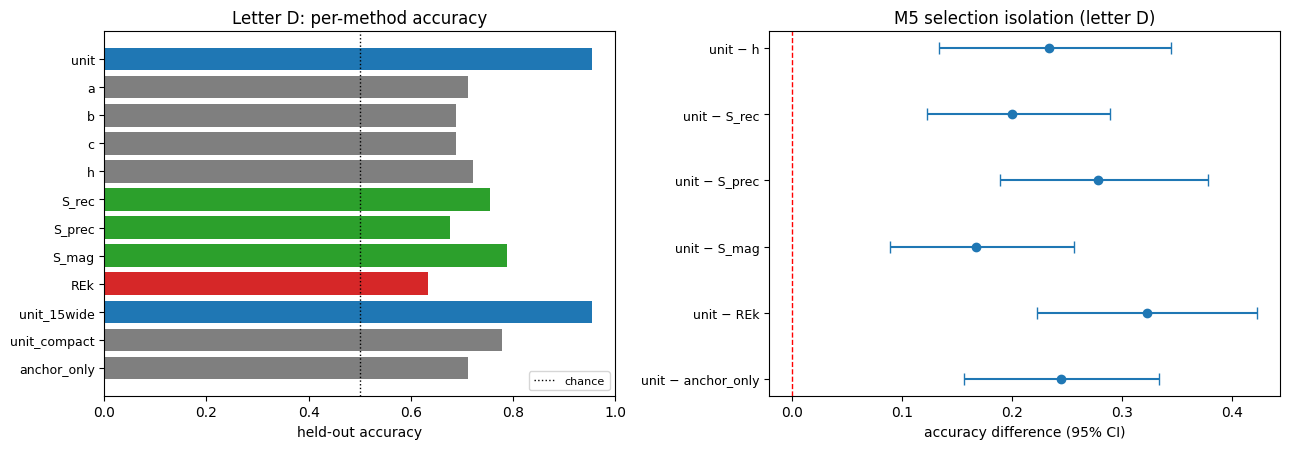


Published AUC table (all 5 letters)  [set-cover-specific win = unit beats h AND S_rec/prec/mag]

  letter   unit      h  S_rec S_prec  S_mag   E1  set_cover
  ---------------------------------------------------------
  L       0.905  0.795  0.860  0.849  0.868    T      False
  O       0.917  0.819  0.850  0.583  0.817    T      False
  T       0.858  0.647  0.828  0.526  0.754    T      False
  I       0.983  0.735  0.819  0.631  0.809    T       True
  D       0.956  0.727  0.755  0.689  0.798    T       True

primary_endpoint : REFRAMED_TO_ELIGIBILITY_AND_SENSIBLE_SELECTION
E1 passes        : 5/5 letters   |   set-cover-specific established : 2/5 (letters I, D)
pooled unit - h  : Δ=+0.188  CI[+0.148, +0.223]  (excl 0 = True)


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- left: per-method accuracy bar chart ---
order = [m for m in METHODS]
accs = [accuracy[m] for m in order]
colors = ["#1f77b4" if m in ("unit", "unit_15wide") else
          ("#2ca02c" if m in SELECTORS else
           ("#d62728" if m == "REk" else "#7f7f7f")) for m in order]
ax1.barh(range(len(order)), accs, color=colors)
ax1.set_yticks(range(len(order))); ax1.set_yticklabels(order, fontsize=9)
ax1.invert_yaxis()
ax1.axvline(0.5, color="k", ls=":", lw=1, label="chance")
ax1.set_xlim(0, 1); ax1.set_xlabel("held-out accuracy")
ax1.set_title(f"Letter {DEMO_LETTER}: per-method accuracy")
ax1.legend(loc="lower right", fontsize=8)

# --- right: forest plot of unit - baseline accuracy diffs ---
bl_order = COMPARE_TO
diffs = [ci[bl]["diff"] for bl in bl_order]
los   = [ci[bl]["diff"] - ci[bl]["ci_lo"] for bl in bl_order]
his   = [ci[bl]["ci_hi"] - ci[bl]["diff"] for bl in bl_order]
ypos = range(len(bl_order))
ax2.errorbar(diffs, ypos, xerr=[los, his], fmt="o", color="#1f77b4", capsize=4)
ax2.axvline(0, color="r", ls="--", lw=1)
ax2.set_yticks(list(ypos)); ax2.set_yticklabels([f"unit − {b}" for b in bl_order], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel("accuracy difference (95% CI)")
ax2.set_title(f"M5 selection isolation (letter {DEMO_LETTER})")
plt.tight_layout(); plt.show()

# --- published AUC table for all 5 letters (context) ---
print("\nPublished AUC table (all 5 letters)  [set-cover-specific win = unit beats h AND S_rec/prec/mag]\n")
hdr = f"  {'letter':6s} {'unit':>6s} {'h':>6s} {'S_rec':>6s} {'S_prec':>6s} {'S_mag':>6s}  {'E1':>3s}  {'set_cover':>9s}"
print(hdr); print("  " + "-" * (len(hdr) - 2))
for L, row in ref["per_letter"].items():
    a = row["AUC"]
    print(f"  {L:6s} {a['unit']:6.3f} {a['h']:6.3f} {a['S_rec']:6.3f} {a['S_prec']:6.3f} {a['S_mag']:6.3f}"
          f"  {str(row['E1_PASS'])[0]:>3s}  {str(row['set_cover_established']):>9s}")

p = ref["pooled_across_letters"]
print(f"\nprimary_endpoint : {ref['primary_endpoint']}")
print(f"E1 passes        : {ref['n_E1_pass']}/5 letters   |   set-cover-specific established : "
      f"{ref['n_joint_E1_and_selection']}/5 (letters I, D)")
sb = p["unit_vs_h"]["stratified_bootstrap"]
print(f"pooled unit - h  : Δ={sb['diff']:+.3f}  CI[{sb['ci_lo']:+.3f}, {sb['ci_hi']:+.3f}]  (excl 0 = {sb['excl_0']})")